In [1]:
%load_ext autoreload
%autoreload 2

# append parent directory to path (../notebooks -> ..)
import os
import sys

sys.path.append(os.path.dirname(os.getcwd()))
os.chdir(os.path.dirname(os.getcwd()))

import accelerate
import lovely_tensors as lt
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import torch
import yaml
from diffusers.optimization import get_scheduler
from omegaconf import OmegaConf
from tqdm.auto import tqdm

from ldns.networks import AutoEncoder, CountWrapper
from ldns.utils.plotting_utils import *
from ldns.networks import Denoiser
from diffusers.training_utils import EMAModel
from diffusers.schedulers import DDPMScheduler

lt.monkey_patch()
#matplotlib.rc_file("matplotlibrc")  # mackelab plotting style

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
## load config and model path
LDNS_path = "monkey_reach_neural_spiking/"

cfg_ae = OmegaConf.load(LDNS_path + "conf/autoencoder-monkey_z=16.yaml")

cfg_yaml = """
denoiser_model:
  C_in: 16
  C: 256
  num_blocks: 6
  bidirectional: True
  num_train_timesteps: 1000
training:
  lr: 0.001
  weight_decay: 0.0
  num_epochs: 2000
  num_warmup_epochs: 50
  batch_size: 512
  random_seed: 42
  precision: "no"
exp_name: diffusion_monkey_velocity_conditioned
"""

cfg = OmegaConf.create(yaml.safe_load(cfg_yaml))
cfg.dataset = cfg_ae.dataset

In [3]:
from ldns.data.monkey import get_monkey_dataloaders

# initialize autoencoder model
ae_model = AutoEncoder(
    C_in=cfg_ae.model.C_in,
    C=cfg_ae.model.C,
    C_latent=cfg_ae.model.C_latent,
    L=cfg_ae.dataset.signal_length,
    num_blocks=cfg_ae.model.num_blocks,
    num_blocks_decoder=cfg_ae.model.get("num_blocks_decoder", cfg_ae.model.num_blocks),
    num_lin_per_mlp=cfg_ae.model.get("num_lin_per_mlp", 2),  # default 2
    bidirectional=cfg_ae.model.get("bidirectional", True),
)

ae_model = CountWrapper(ae_model)

# load pretrained autoencoder
ae_model.load_state_dict(torch.load(LDNS_path + "exp/autoencoder-monkey_z=16/model.pt"), strict=False)

# set random seeds
torch.manual_seed(cfg.training.random_seed)
np.random.seed(cfg.training.random_seed)

# get dataloaders
train_dataloader, val_dataloader, test_dataloader = get_monkey_dataloaders(
    cfg_ae.dataset.task, cfg_ae.dataset.datapath, bin_width=5, batch_size=cfg_ae.training.batch_size
)

# setup accelerator
accelerator = accelerate.Accelerator(
    mixed_precision=cfg_ae.training.get("precision", "no"),
)

# prepare model and data for training
ae_model = accelerator.prepare(ae_model)

(
    train_dataloader,
    val_dataloader,
    test_dataloader,
) = accelerator.prepare(
    train_dataloader,
    val_dataloader,
    test_dataloader,
)

Loaded train data dict from /athena/grosenicklab/scratch/sar4018/ruchi_wcm_project/diffusion-model/LDNS/ldns/data/000128/sub-Jenkins/monkey_mc_maze_data_dict_train_split_5.pkl
Loaded val data dict from /athena/grosenicklab/scratch/sar4018/ruchi_wcm_project/diffusion-model/LDNS/ldns/data/000128/sub-Jenkins/monkey_mc_maze_data_dict_val_split_5.pkl
Loaded train data dict from /athena/grosenicklab/scratch/sar4018/ruchi_wcm_project/diffusion-model/LDNS/ldns/data/000128/sub-Jenkins/monkey_mc_maze_data_dict_train_split_5.pkl
Loaded val data dict from /athena/grosenicklab/scratch/sar4018/ruchi_wcm_project/diffusion-model/LDNS/ldns/data/000128/sub-Jenkins/monkey_mc_maze_data_dict_val_split_5.pkl
Task: mc_maze, Bin width: 5 ms
Train: 2008, Val: 71, Test: 216


In [4]:
(
    train_dataloader,
    val_dataloader,
    test_dataloader,
) = accelerator.prepare(
    train_dataloader,
    val_dataloader,
    test_dataloader,
)

# Create dataset containing behavior, behavior angle, spike dataset, latents from ae
from ldns.data.monkey import LatentMonkeyDataset

latent_dataset_train = LatentMonkeyDataset(train_dataloader, ae_model, clip=False)

latent_dataset_val = LatentMonkeyDataset(
    val_dataloader,
    ae_model,
    latent_means=latent_dataset_train.latent_means,
    latent_stds=latent_dataset_train.latent_stds,
    clip=False,
)

latent_dataset_test = LatentMonkeyDataset(
    test_dataloader,
    ae_model,
    latent_means=latent_dataset_train.latent_means,
    latent_stds=latent_dataset_train.latent_stds,
    clip=False,
)

print(latent_dataset_train[0].keys())
print(latent_dataset_train[0]['signal'].shape)
print(latent_dataset_train[0]['latent'].shape)
print(latent_dataset_train[0]['behavior_angle'].shape)

Creating latent dataset:   0%|          | 0/32 [00:00<?, ?it/s]

Creating latent dataset:   0%|          | 0/2 [00:00<?, ?it/s]

Creating latent dataset:   0%|          | 0/4 [00:00<?, ?it/s]

dict_keys(['signal', 'latent', 'behavior', 'behavior_angle'])
torch.Size([182, 140])
torch.Size([16, 140])
torch.Size([1])


In [6]:
train_latent_dataloader = torch.utils.data.DataLoader(
    latent_dataset_train,
    batch_size=cfg.training.batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_latent_dataloader = torch.utils.data.DataLoader(
    latent_dataset_val,
    batch_size=cfg.training.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

test_latent_dataloader = torch.utils.data.DataLoader(
    latent_dataset_test,
    batch_size=cfg.training.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

num_batches = len(train_latent_dataloader)

# check if signal length is power of 2
if cfg.dataset.signal_length & (cfg.dataset.signal_length - 1) != 0:
    cfg.training.precision = "no"  # torch.fft doesnt support half if L!=2^x

# prepare the denoiser model and dataset
(
    train_latent_dataloader,
    val_latent_dataloader,
    test_latent_dataloader,
) = accelerator.prepare(
    train_latent_dataloader,
    val_latent_dataloader,
    test_latent_dataloader,
)


In [7]:
denoiser = Denoiser(
    C_in=cfg.denoiser_model.C_in + 2,  # add 2 for behavior velocity
    C=cfg.denoiser_model.C,
    L=cfg.dataset.signal_length,
    num_blocks=cfg.denoiser_model.num_blocks,
    bidirectional=cfg.denoiser_model.get("bidirectional", True),
)

# initial values may be way off, scaling down the output layer makes training faster
denoiser.conv_out.weight.data = denoiser.conv_out.weight.data * 0.1
denoiser.conv_out.bias.data = denoiser.conv_out.bias.data * 0.1

scheduler = DDPMScheduler(
    num_train_timesteps=cfg.denoiser_model.num_train_timesteps, clip_sample=False, beta_schedule="linear"
)

optimizer = torch.optim.AdamW(denoiser.parameters(), lr=cfg.training.lr)  # default wd=0.01 for now


num_batches = len(train_latent_dataloader)
lr_scheduler = get_scheduler(
    name="cosine",
    optimizer=optimizer,
    num_warmup_steps=num_batches * cfg.training.num_warmup_epochs,  # warmup for 10% of epochs
    num_training_steps=num_batches
    * cfg.training.num_epochs
    * 1.3,  # total number of steps until 0 lr, we use 1.3 to no go all the way to 0 lr
)

# prepare the denoiser model and dataset
(
    denoiser,
    optimizer,
    lr_scheduler,
) = accelerator.prepare(
    denoiser,
    optimizer,
    lr_scheduler,
)

ema_model = EMAModel(denoiser)

from ldns.utils import count_parameters
print(count_parameters(denoiser) / 1e6, "M parameters")

2.701202 M parameters


In [8]:
# load official model checkpoint (optional)
denoiser.load_state_dict(torch.load(LDNS_path + f"exp/{cfg.exp_name}/model.pt"))

ema_model = EMAModel(denoiser)  # eval and no grad

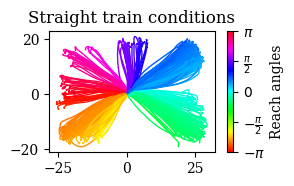

In [9]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman', 'Georgia']
from matplotlib import cm, colors

def angle_to_rgba(angle, cmap):
    # map angle in [-pi, pi] to u in [0, 1] and take color from chosen cmap
    u = (angle + np.pi) / (2*np.pi)
    return cmap(u)

ticks = np.linspace(-np.pi, np.pi, 5)
tick_positions = (ticks + np.pi) / (2*np.pi)   # map to [0,1]

# === TRAIN ===
train_traj = np.cumsum(latent_dataset_train.behavior, axis=-1)
angle_train_behavior = np.arctan2(train_traj[:, 1, -1], train_traj[:, 0, -1])
angle_train_behavior_init = np.arctan2(train_traj[:, 1, 50], train_traj[:, 0, 50])

st_train_indices_predicted = np.where(np.abs(angle_train_behavior_init - angle_train_behavior) < 0.3)[0]
#cmap_train = plt.get_cmap("twilight")
cmap_train = plt.get_cmap("hsv")
plt.figure(figsize=cm2inch(8, 4))
for idx in st_train_indices_predicted:
    plt.plot(
        train_traj[idx, 0, :],
        train_traj[idx, 1, :],
        color=angle_to_rgba(angle_train_behavior[idx], cmap_train),
        linewidth=1.0,
    )
plt.gca().set_aspect('equal', adjustable='box')

# colorbar for train on [-pi, pi]
sm_train = cm.ScalarMappable(cmap=cmap_train, norm=colors.Normalize(0, 1))
sm_train.set_array([])
cbar = plt.colorbar(sm_train, ticks=tick_positions, ax=plt.gca())
cbar.ax.set_yticklabels([r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"])
cbar.set_label("Reach angles")
plt.title("Straight train conditions")
plt.show()

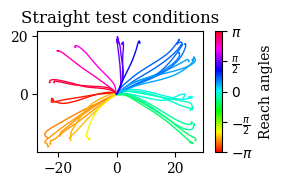

In [10]:
# === TEST ===
# get reach angles and find straight reaches
test_traj = np.cumsum(latent_dataset_test.behavior, axis=-1)
angle_test_behavior = np.arctan2(test_traj[:, 1, -1], test_traj[:, 0, -1])
angle_test_behavior_init = np.arctan2(test_traj[:, 1, 50], test_traj[:, 0, 50])
#straight_indices_predicted = np.where(np.abs(angle_test_behavior_init - angle_test_behavior) < 0.3)[0]
straight_indices_predicted = np.where(
    (np.abs(angle_test_behavior_init - angle_test_behavior) < 0.3) &
    (~np.isin(np.arange(len(angle_test_behavior)), st_train_indices_predicted))
)[0]

# === TEST ===
cmap_test = plt.get_cmap("hsv")
plt.figure(figsize=cm2inch(8, 4))
for idx in straight_indices_predicted:
    plt.plot(
        test_traj[idx, 0, :],
        test_traj[idx, 1, :],
        color=angle_to_rgba(angle_test_behavior[idx], cmap_test),
        linewidth=1.0,
    )
plt.gca().set_aspect('equal', adjustable='box')
ticks = np.linspace(-np.pi, np.pi, 5)
tick_positions = (ticks + np.pi) / (2*np.pi)   # map to [0,1]
sm_test = cm.ScalarMappable(cmap=cmap_test, norm=colors.Normalize(0, 1))
sm_test.set_array([])
cbar = plt.colorbar(sm_test, ticks=tick_positions, ax=plt.gca())
cbar.ax.set_yticklabels([r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"])
cbar.set_label("Reach angles")
plt.title("Straight test conditions")
# plt.xlabel('x position')
# plt.ylabel('y position')
plt.show()


In [11]:
# Getting diffusion latents of neural spikes (Z-space)
from pathlib import Path
sys.path.append(LDNS_path)

ema_denoiser_avg = ema_model.averaged_model
ema_denoiser_avg.eval()

from ddim import *

real_train_latents = latent_dataset_train.latents.to(device)
real_train_latents = real_train_latents * latent_dataset_train.latent_stds.to(device) + latent_dataset_train.latent_means.to(device)
latent_batch_train_images = real_train_latents.to(device)

batch_train_labels = latent_dataset_train.behavior.to(device)


real_test_latents = latent_dataset_test.latents.to(device)
real_test_latents = real_test_latents * latent_dataset_train.latent_stds.to(device) + latent_dataset_train.latent_means.to(device)
latent_batch_test_images = real_test_latents.to(device)

batch_test_labels = latent_dataset_test.behavior.to(device)

inf_steps = 1000

# Invert the ldns latent train dataset to ddim latents
ddim_train = invert(latent_batch_train_images, num_inference_steps=inf_steps, labels=batch_train_labels, 
                    scheduler=scheduler, ema_denoiser_avg=ema_denoiser_avg, cfg=cfg).detach().cpu().numpy()
ddim_test = invert(latent_batch_test_images, num_inference_steps=inf_steps, labels=batch_test_labels, 
                   scheduler=scheduler, ema_denoiser_avg=ema_denoiser_avg, cfg=cfg).detach().cpu().numpy()

#ddim_train = np.load(f"k-dim-cebra-data/Z_train_data.npy") # ddim latents of train data
#ddim_test = np.load(f"k-dim-cebra-data/Z_test_data.npy")# ddim latents of test data

n_train, n_latents, time_steps = ddim_train.shape
ddim_reshaped_train = ddim_train.transpose(0, 2, 1).reshape(-1, n_latents)
print(ddim_reshaped_train.shape)

n_test = len(ddim_test)
ddim_reshaped_test = ddim_test.transpose(0, 2, 1).reshape(-1, n_latents)
print(ddim_reshaped_test.shape)

vel_reshaped_train = latent_dataset_train.behavior.detach().cpu().numpy().transpose(0, 2, 1).reshape(-1, 2)
print(vel_reshaped_train.shape)

vel_reshaped_test = latent_dataset_test.behavior.detach().cpu().numpy().transpose(0, 2, 1).reshape(-1, 2)
print(vel_reshaped_test.shape)

cuda


  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

(281120, 16)
(30240, 16)
(281120, 2)
(30240, 2)


In [12]:
# Contrastive embedding of Z-data 
from Cebra import cebra_model
cebra_model.fit(ddim_reshaped_train, vel_reshaped_train)
cebra_result_train = cebra_model.transform(ddim_reshaped_train)

pos: -2.7144 neg:  7.9601 total:  5.2457


Text(0.5, 1.0, 'train spikes in C-space')

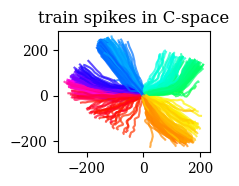

In [13]:
#cebra_result_train = np.load(f"k-dim-cebra-data/{key}.npy")
dim = 2
cebra_result_train_reshaped = cebra_result_train.reshape(n_train, time_steps, dim).transpose(0, 2, 1)
#cebra_result_test_reshaped = cebra_result_test.reshape(n_test, time_steps, dim).transpose(0, 2, 1)

plt.figure(figsize=cm2inch(5, 4))
for idx in st_train_indices_predicted:
    plt.plot(
        np.cumsum(cebra_result_train_reshaped, axis=-1)[idx, 0, :],
        np.cumsum(cebra_result_train_reshaped, axis=-1)[idx, 1, :],
        color=angle_to_color(angle_train_behavior[idx]), alpha=0.7,
    )
plt.title("train spikes in C-space")    

In [14]:
# transformation of test reaches to C-space
import cebra
import sklearn.metrics

decoder1 = cebra.KNNDecoder(n_neighbors=9, metric="cosine")
decoder2 = cebra.KNNDecoder(n_neighbors=15, metric="euclidean")

y_train = latent_dataset_train.behavior.permute(0,2,1).reshape(n_train,-1)
y_test = latent_dataset_test.behavior.permute(0,2,1).reshape(n_test,-1)
c_train = cebra_result_train.reshape(n_train,-1)

decoder1.fit(y_train, c_train)
p_test_traj = decoder1.predict(y_test) 

decoder2.fit(c_train, ddim_reshaped_train.reshape(n_train,-1))
H_cebra = decoder2.predict(p_test_traj).reshape(n_test, time_steps, n_latents).transpose(0, 2, 1)
print(decoder2.score(p_test_traj, ddim_reshaped_test.reshape(n_test,-1)))

0.5203732058174407


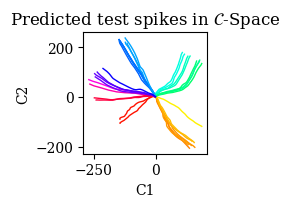

In [15]:
# === Projected TEST Trajectory ===
pred_test_traj = p_test_traj.reshape(n_test,time_steps,2).transpose(0,2,1)

cmap_test = plt.get_cmap("hsv")
plt.figure(figsize=cm2inch(5, 4))
for idx in straight_indices_predicted:
#for idx in st_train_indices_predicted:
    plt.plot(
        np.cumsum(pred_test_traj,axis=-1)[idx, 0, :],
        np.cumsum(pred_test_traj,axis=-1)[idx, 1, :],
        color=angle_to_rgba(angle_test_behavior[idx], cmap_test),
        linewidth=1.0,
    )
plt.gca().set_aspect('equal', adjustable='box')
ticks = np.linspace(-np.pi, np.pi, 5)
tick_positions = (ticks + np.pi) / (2*np.pi)   # map to [0,1]
sm_test = cm.ScalarMappable(cmap=cmap_test, norm=colors.Normalize(0, 1))
sm_test.set_array([])
#cbar = plt.colorbar(sm_test, ticks=tick_positions, ax=plt.gca())
#cbar.ax.set_yticklabels([r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"])
#cbar.set_label("reach angles")
plt.title("Predicted test spikes in $\mathcal{C}$-Space")
plt.xlabel('C1')
plt.ylabel('C2')
plt.show()

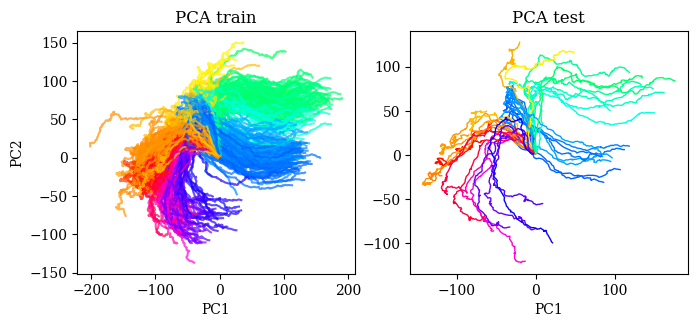

In [21]:
# PCA of Z-data 
from sklearn.decomposition import PCA
k = 2
pca = PCA(n_components=k)
pca_result = pca.fit_transform(ddim_reshaped_train)
pca_result_test = pca.transform(ddim_test.transpose(0, 2, 1).reshape(-1, n_latents))
H_pca = pca.inverse_transform(y_test.reshape(n_test*time_steps, k)).reshape(n_test, time_steps, n_latents).transpose(0, 2, 1)

Z_pca_train = pca_result.reshape(n_train, time_steps, k).transpose(0, 2, 1)
Z_pca_test = pca_result_test.reshape(n_test, time_steps, k).transpose(0, 2, 1)

plt.figure(figsize=cm2inch(20, 8))

plt.subplot(1,2,1)
for idx in st_train_indices_predicted:
    plt.plot(
        np.cumsum(Z_pca_train, axis=-1)[idx, 0, :],
        np.cumsum(Z_pca_train, axis=-1)[idx, 1, :],
        color=angle_to_rgba(angle_train_behavior[idx],cmap_train), alpha=0.7,
    )
plt.title("PCA train")    
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1,2,2)
for idx in straight_indices_predicted:
    plt.plot(
        np.cumsum(Z_pca_test, axis=-1)[idx, 0, :],
        np.cumsum(Z_pca_test, axis=-1)[idx, 1, :],
        color=angle_to_rgba(angle_test_behavior[idx], cmap_test),
        linewidth=1.0,
    )
plt.title("PCA test")
plt.xlabel('PC1')
#plt.ylabel('PC2')
plt.show()    

In [23]:
train_vel = latent_dataset_train.behavior
ema_denoiser_avg = ema_model.averaged_model
ema_denoiser_avg.eval()


# Generate test data in Z-space
pred_test_ddim_latents = torch.tensor(H_cebra, dtype=torch.float32).to(device)
pred_test_ddim_latents = pred_test_ddim_latents * latent_dataset_train.latent_stds.to(device) + latent_dataset_train.latent_means.to(device)
batch_test_labels = latent_dataset_test.behavior.to(device)
ddim_samp_recon_test = sample(start_latents=pred_test_ddim_latents, num_inference_steps=inf_steps, labels=batch_test_labels,
                             scheduler=scheduler, ema_denoiser_avg=ema_denoiser_avg, cfg=cfg)


# unnormalize ddim latents
ddim_recon_test_latents = ddim_samp_recon_test * latent_dataset_train.latent_stds.to(device) + latent_dataset_train.latent_means.to(device)

## decode both latents to rates
with torch.no_grad():
    ddim_recon_test_rates = ae_model.decode(ddim_recon_test_latents).cpu()

recons_test_rates =  ddim_recon_test_rates  

# decode both latents to rates
with torch.no_grad():
    real_test_rates = ae_model.decode(real_test_latents).cpu()

  0%|          | 0/999 [00:00<?, ?it/s]

In [24]:
# Evaluation
import numpy as np
from scipy.spatial import procrustes

# Initialize lists
tae_ddim, rmse_ddim = [], []
procrustes_ddim = []

# Loop over trials
for i in range(real_test_rates.shape[0]):
    
    # Convert tensors to NumPy arrays
    real_np = ddim_test[i]
    ddim_np = H_cebra[i]
    
    # Total Absolute Error
    tae_ddim.append(np.sum(np.abs(ddim_np - real_np)))
    
    # Mean Squared Error
    rmse_ddim.append(np.sqrt(np.mean((ddim_np - real_np) ** 2)))
    
    # Procrustes Distance
    _, _, d_ddim = procrustes(real_np, ddim_np)
    procrustes_ddim.append(d_ddim)

# Convert to NumPy arrays
tae_ddim = np.array(tae_ddim)
rmse_ddim = np.array(rmse_ddim)
procrustes_ddim = np.array(procrustes_ddim)

# Print results
print("RMSE (CEBRA): {:.4f} ± {:.4f}".format(rmse_ddim.mean(), rmse_ddim.std()))
print("Total Absolute Error (CEBRA): {:.2f} ± {:.2f}".format(tae_ddim.mean(), tae_ddim.std()))
print("Z-score (mean/std) - CEBRA: {:.4f}".format(tae_ddim.mean() / tae_ddim.std()))
print("Procrustes Distance (CEBRA): {:.4f} ± {:.4f}".format(procrustes_ddim.mean(), procrustes_ddim.std()))

RMSE (CEBRA): 0.6816 ± 0.0480
Total Absolute Error (CEBRA): 1116.12 ± 90.07
Z-score (mean/std) - CEBRA: 12.3914
Procrustes Distance (CEBRA): 0.0846 ± 0.0222


In [25]:
# Initialize lists
tae_pca, rmse_pca = [], []
procrustes_pca = []

# Loop over trials
for i in range(real_test_rates.shape[0]):
    
    # Convert tensors to NumPy arrays
    real_np = ddim_test[i]
    ddim_np = H_pca[i]
    
    # Total Absolute Error
    tae_pca.append(np.sum(np.abs(ddim_np - real_np)))
    
    # Mean Squared Error
    rmse_pca.append(np.sqrt(np.mean((ddim_np - real_np) ** 2)))
    
    # Procrustes Distance
    _, _, d_ddim = procrustes(real_np, ddim_np)
    procrustes_pca.append(d_ddim)

# Convert to NumPy arrays
tae_pca = np.array(tae_pca)
rmse_pca = np.array(rmse_pca)
procrustes_pca = np.array(procrustes_pca)

# Print results
print("RMSE (PCA): {:.4f} ± {:.4f}".format(rmse_pca.mean(), rmse_pca.std()))
print("Total Absolute Error (PCA): {:.2f} ± {:.2f}".format(tae_pca.mean(), tae_pca.std()))
print("Z-score (mean/std) - PCA: {:.4f}".format(tae_pca.mean() / tae_pca.std()))
print("Procrustes Distance (PCA): {:.4f} ± {:.4f}".format(procrustes_pca.mean(), procrustes_pca.std()))

RMSE (PCA): 1.0437 ± 0.0373
Total Absolute Error (PCA): 1804.89 ± 74.37
Z-score (mean/std) - PCA: 24.2685
Procrustes Distance (PCA): 0.7162 ± 0.0570


sample index: 198


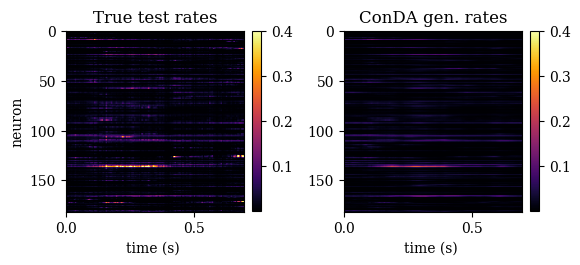

In [33]:
# Visualization
fps = 1000 / 5
time_points = 140
time_interval = 1 / fps
second_ticks = fps / 2  # ticks every 0.25 seconds
xticks = np.arange(0, time_points, second_ticks)

import random
#sample_idx = np.where(diffs1 == np.min(diffs1))[0]
sample_idx = random.randint(0, 215)
print("sample index:", sample_idx)
#idx = 214
# Plot a grid of comparisons
fig, ax = plt.subplots(1, 2, figsize=cm2inch(15, 7), sharex=True)
ax = ax.flatten()

im = ax[0].imshow(real_test_rates[idx], aspect="auto", cmap = 'inferno',vmax=0.4)
fig.colorbar(im, ax=ax[0], orientation="vertical", fraction=0.046, pad=0.04)
ax[0].set_xticks(xticks)
ax[0].set_xticklabels([f"{x * time_interval:.1f}" for x in xticks])
ax[0].set_xlabel("time (s) ")
ax[0].set_ylabel("neuron")
ax[0].set_title('True test rates')

im1 = ax[1].imshow(recons_test_rates[idx], aspect="auto", cmap = 'inferno',vmax=0.4)
fig.colorbar(im1, ax=ax[1], orientation="vertical", fraction=0.046, pad=0.04)
ax[1].set_xlabel("time (s) ")
#ax[1].set_ylabel("neuron")
ax[1].set_title('ConDA gen. rates')
plt.tight_layout()
plt.show()

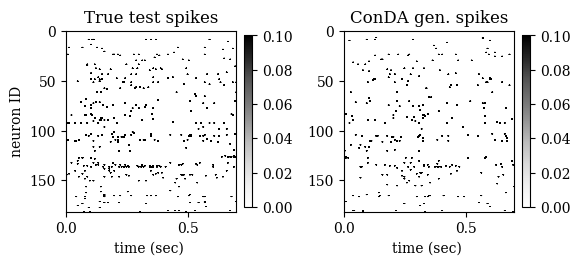

In [34]:
# Plot a grid of comparisons
fig, ax = plt.subplots(1, 2, figsize=cm2inch(15, 7), sharex=True)
ax = ax.flatten()

real_test_spikes = torch.poisson(real_test_rates)
im = ax[0].imshow(real_test_spikes[idx], aspect="auto", cmap ='Greys', vmax=0.1)
fig.colorbar(im, ax=ax[0], orientation="vertical", fraction=0.046, pad=0.04, format="%.2f")
ax[0].set_xticks(xticks)
ax[0].set_xticklabels([f"{x * time_interval:.1f}" for x in xticks])
ax[0].set_xlabel("time (sec) ")
ax[0].set_ylabel("neuron ID")
ax[0].set_title('True test spikes')

ddim_test_spikes = torch.poisson(recons_test_rates)
im1 = ax[1].imshow(ddim_test_spikes[idx], aspect="auto", cmap ='Greys', vmax=0.1)
fig.colorbar(im1, ax=ax[1], orientation="vertical", fraction=0.046, pad=0.04, format="%.2f")
ax[1].set_xlabel("time (sec) ")
ax[1].set_title('ConDA gen. spikes')
#ax[1].set_ylabel("neuron")
plt.tight_layout()
plt.show()

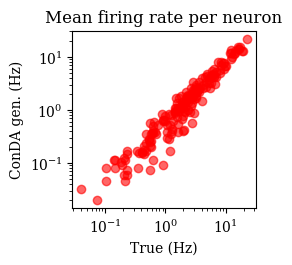

In [41]:
# Using ConDA
import numpy as np

def mean_firing_rate_per_neuron(data, bin_ms=5.0):
    """
    data: torch.Tensor or np.ndarray of shape (N_samples, N_neurons, T)
          spike counts per bin
    bin_ms: bin width in milliseconds (e.g., 5 ms)

    Returns:
        mean_rate_hz: (N_neurons,)
    """
    if hasattr(data, "detach"):
        data = data.detach().cpu().numpy()

    # mean spikes per bin per neuron
    mean_spikes_per_bin = data.mean(axis=(0, 2))  # average over samples and time

    # convert to Hz
    mean_rate_hz = mean_spikes_per_bin * (1000.0 / bin_ms)
    return mean_rate_hz

mean_rate_real = mean_firing_rate_per_neuron(real_test_spikes, bin_ms=5.0)
mean_rate_pred = mean_firing_rate_per_neuron(ddim_test_spikes, bin_ms=5.0)

import matplotlib.pyplot as plt

plt.figure(figsize=cm2inch(7, 7))
plt.scatter(mean_rate_real, mean_rate_pred, alpha=0.6, c='r')

plt.xscale("log")
plt.yscale("log")

# lims = [
#     max(mean_rate_real[mean_rate_real > 0].min(),
#         mean_rate_pred[mean_rate_pred > 0].min()),
#     max(mean_rate_real.max(), mean_rate_pred.max())
# ]
# plt.plot(lims, lims, 'k--')

plt.xlabel("True (Hz)")
plt.ylabel("ConDA gen. (Hz)")
plt.title("Mean firing rate per neuron")
plt.tight_layout()
plt.show()


In [39]:
from scipy.stats import pearsonr

r, _ = pearsonr(mean_rate_real, mean_rate_pred)
print(f"Pearson r = {r:.2f}")

Pearson r = 0.98
